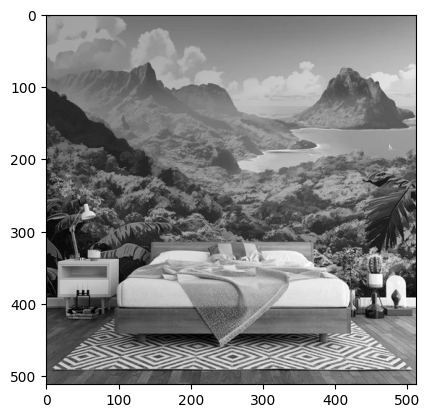

In [5]:
import cv2
import os
from matplotlib import pyplot as plt

fileName = 'image.webp'
if not os.path.exists(fileName):
  open(fileName, 'wb').write()

img = cv2.imread("image.webp")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap=plt.get_cmap('gray'))

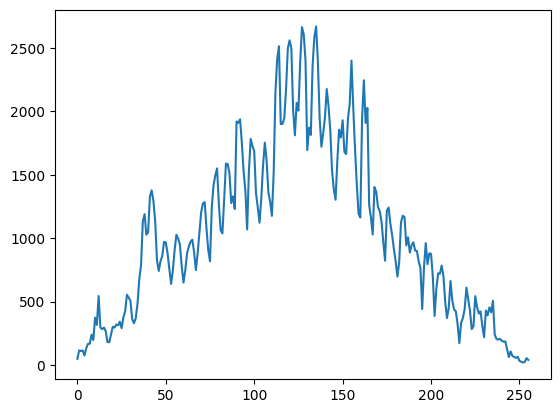

In [6]:
histogram = cv2.calcHist([img], [0], None, [256], [0, 256])

plt.plot(histogram)
plt.show()

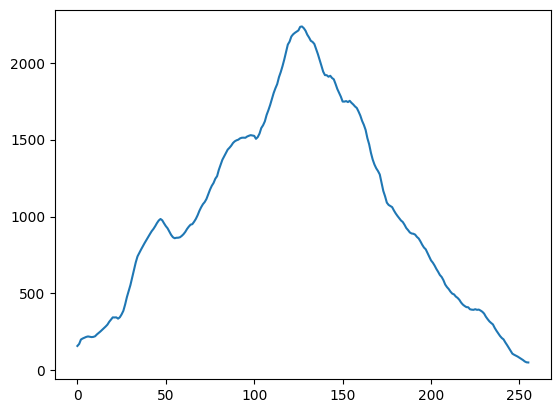

In [22]:
def getVal(x, d):
    l = max(x - d, 0)
    r = min(x + d, 255)

    return sum(histogram[l:(r + 1)]) / (r - l + 1)

newHistogram = [0] * 256

for i in range(0, 256):
    newHistogram[i] = getVal(i, 10)

plt.plot(newHistogram)
plt.show()

In [ ]:
import bisect as bs

for l in range(0, 255):
    for r in range(l + 1, 255 + 1):
        bs.bisect_left(newHistogram[l:(r + 1)])

16


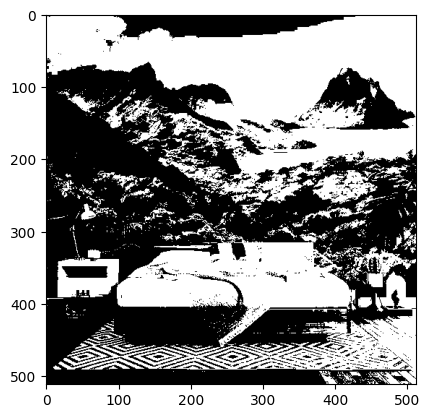

In [2]:
height, width = img.shape

for r in range(height):
  for c in range(width):
    if img[r, c] < 128:
      img[r, c] = 0
    else:
      img[r, c] = 255

plt.imshow(img, cmap=plt.get_cmap('gray'))